Market stats 20251231-1Y, non nones count: 120032, needs 120032


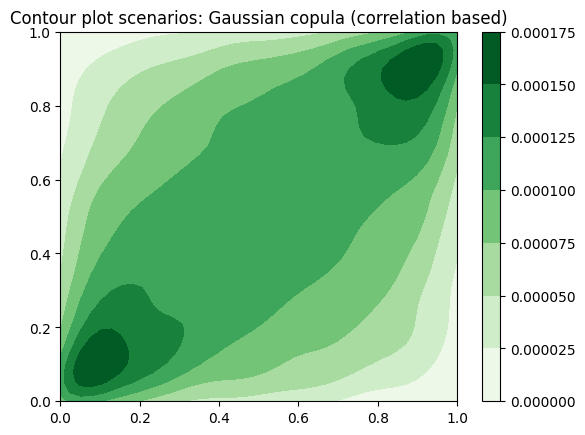

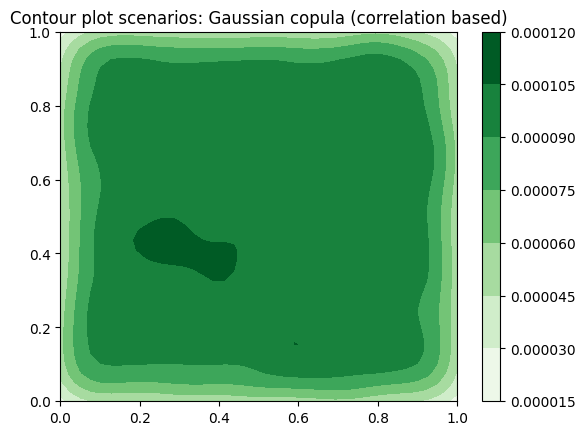

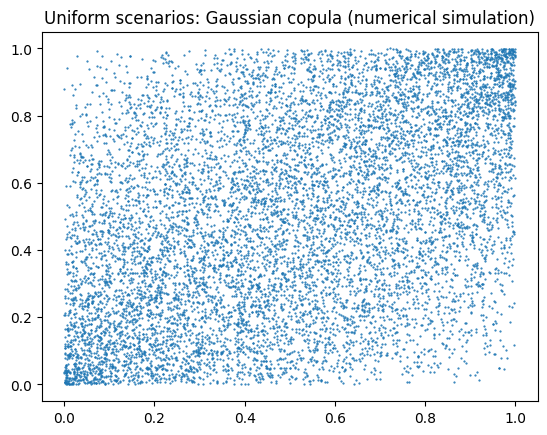

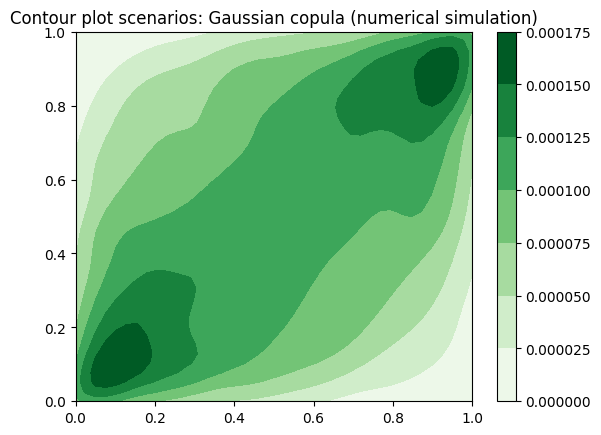

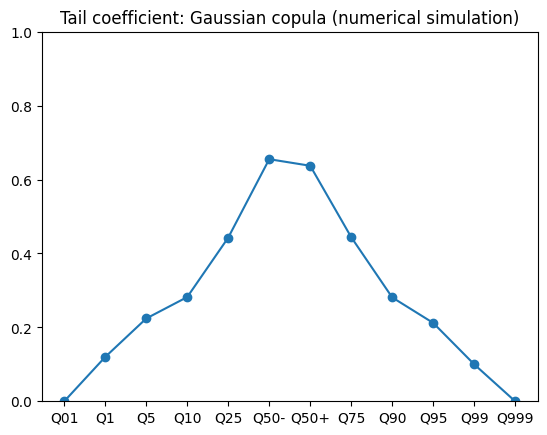

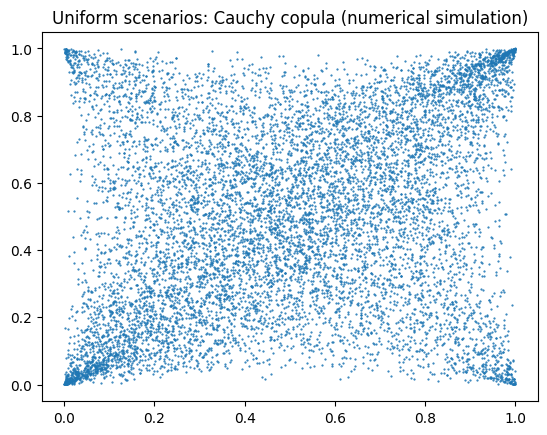

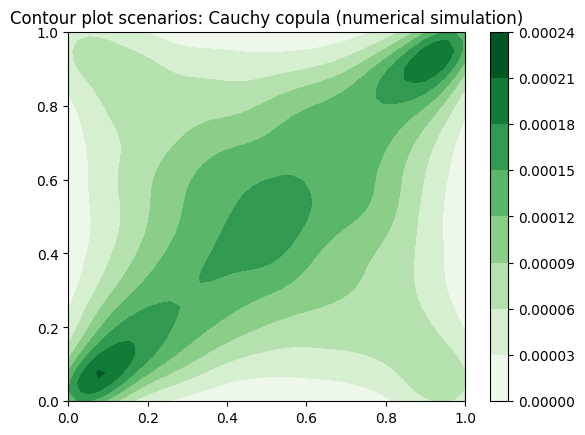

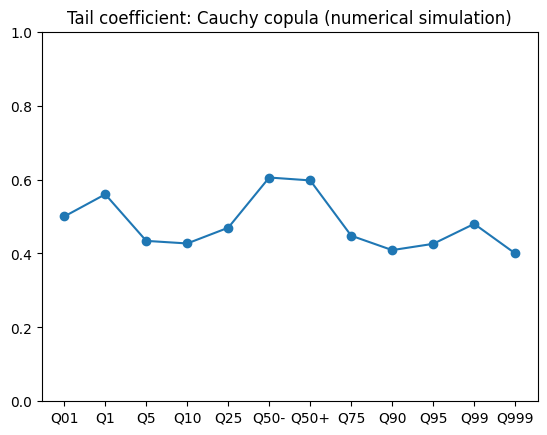

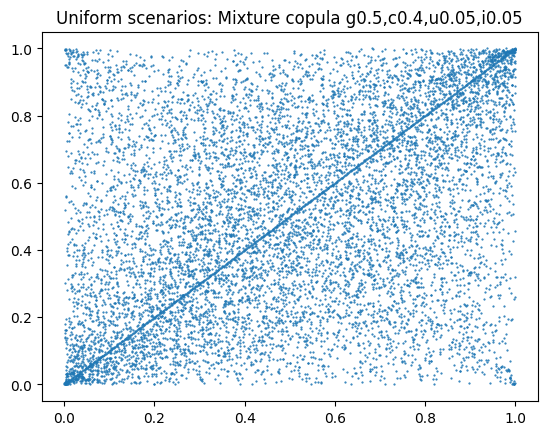

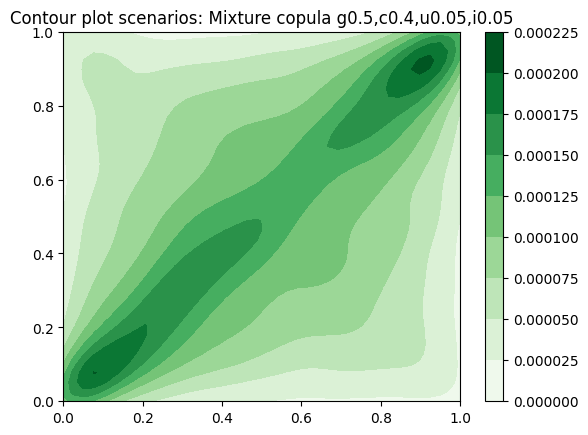

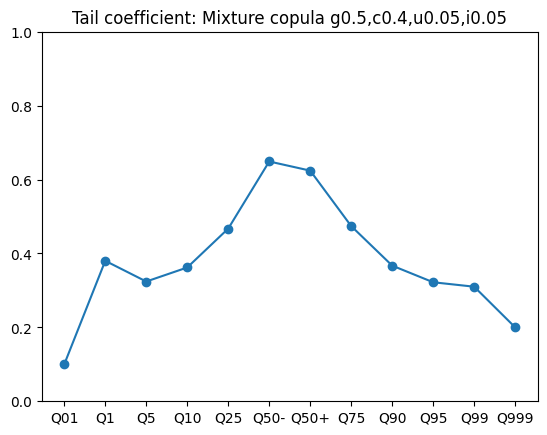

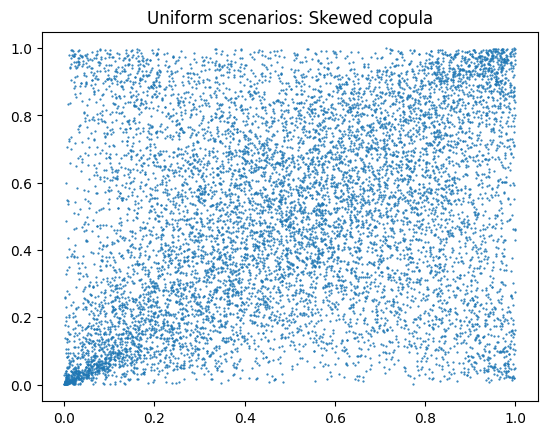

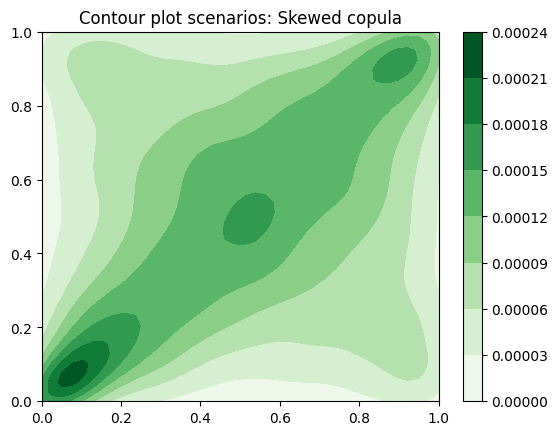

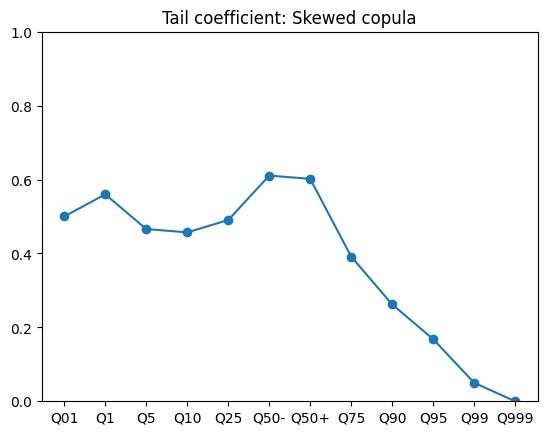

In [7]:
import market as mkt
import jointsim as js
import var as v
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta

relpath = os.path.dirname(os.path.abspath(''))
ptf_name = 'SP500_LongAll'
output_path_part = 'C:\\Temp'
cob_date_str='20251231'

ptf_df = pd.read_csv(f'{relpath}\\data\\portfolios\\{ptf_name}.csv')
ptf_names, ptf_wghts = list(ptf_df['Symbol']), list(ptf_df['Weight'])

market = mkt.Market(name=ptf_name, cob_date_str=cob_date_str, ticker_list=ptf_names, period_years=7, interval='1d', cache_path=output_path_part)
market.load_history()
returns = market.get_logreturns(cob_date_str=cob_date_str, sub_period_years=1)


copula = js.GaussCopulaCorr(returns, [1.0]*len(ptf_names))
copula.get_sims(10000)
copula.plot_contour(0, 1)

copula = js.GaussCopulaCorr(returns, [1.0]*len(ptf_names))
copula.get_sims(10000,override_corr=0.0)
copula.plot_contour(0, 1)

copula = js.GaussCopulaNum(returns, [1.0]*len(ptf_names))
copula.get_sims(10000)
copula.plot_sims(0, 1)
copula.plot_contour(0, 1)
copula.plot_tailcoef(0, 1)

copula = js.CauchyCopulaNum(returns, [1.0]*len(ptf_names))
copula.get_sims(10000)
copula.plot_sims(0, 1)
copula.plot_contour(0, 1)
copula.plot_tailcoef(0, 1)

copula = js.MixCopulaNum(returns, [1.0]*len(ptf_names), weights=[0.5, 0.4, 0.05, 0.05])
copula.get_sims(10000)
copula.plot_sims(0, 1)
copula.plot_contour(0, 1)
copula.plot_tailcoef(0, 1)

weights = [0.95]*484
copula = js.SkewCopulaNum(returns, [1.0]*len(ptf_names), weights=weights)
copula.get_sims(10000)
copula.plot_sims(0, 1)
copula.plot_contour(0, 1)
copula.plot_tailcoef(0, 1)





In [ ]:
import market as mkt
import jointsim as js
import var as v
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

relpath = os.path.dirname(os.path.abspath(''))
ptf_name = 'SP500_Hedged' # 'SP500_Hedged'
output_path_part = 'C:\\Temp'
#meth_list = [('GaussCopulaNum', 'VarSim'), ('CauchyCopulaNum', 'VarSim'), ('HistSimulation', 'VarSim'), ('MixCopulaNum', 'VarSim', [0.4, 0.4, 0.1, 0.1])]
meth_list = [('GaussCopulaNum', 'VarSim'), ('CauchyCopulaNum', 'VarSim'), ('MixCopulaNum', 'VarSim', [0.4, 0.4, 0.1, 0.1]), ('MixCopulaNum', 'VarSim', [0.4, 0.4, 0.2, 0.0]), ('MixCopulaNum', 'VarSim', [0.4, 0.4, 0.0, 0.2])]
cob_date_str='20251231'
figpath = 'C:\\dev\\MLCopula\\document\\figures'

ptf_df = pd.read_csv(f'{relpath}\\data\\portfolios\\{ptf_name}.csv')
ptf_names, ptf_wghts = list(ptf_df['Symbol']), list(ptf_df['Weight'])

market = mkt.Market(name=ptf_name, cob_date_str=cob_date_str, ticker_list=ptf_names, period_years=7, interval='1d', cache_path=output_path_part)
market.load_history()

res = pd.DataFrame(data=None, columns=range(len(meth_list)+1))
res2 = pd.DataFrame(data=None, columns=range(len(meth_list)+1))
res3 = pd.DataFrame(data=None, columns=range(len(meth_list)+1))
for i in range(75):
    new_cob_date = datetime.strptime(cob_date_str, '%Y%m%d').date() - timedelta(days=30*i)
    returns = market.get_logreturns(cob_date_str=new_cob_date.strftime('%Y%m%d'), sub_period_years=1)
    col_res, date_res, date_res2, date_res3 = ['COB'], [new_cob_date], [new_cob_date], [new_cob_date]
    
    for meth in meth_list:
        print(f'{meth[0]}-{meth[1]}')
        copula = getattr(js, meth[0])

        joint_sim = copula(returns, [1.0]*len(ptf_names), seed=0) if meth[0] != 'MixCopulaNum' else copula(returns, [1.0]*len(ptf_names), seed=0, weights=meth[2])

        var_meth = getattr(v, meth[1])
        port_sim = var_meth(returns, market.spot, joint_sim, np.array(ptf_wghts), method='midpoint')
        port_sim.calculate_pnls(10000)
        port_var = round(port_sim.get_quantile(0.99)/port_sim.get_port_value()*100,2)
        port_var2 = round(port_sim.get_quantile(0.995)/port_sim.get_port_value()*100,2)
        port_var3 = round(port_sim.get_quantile(0.999)/port_sim.get_port_value()*100,2)
        date_res.append(port_var); date_res2.append(port_var2); date_res3.append(port_var3); col_res.append(port_sim.name)

    res.columns, res2.columns, res3.columns = col_res, col_res, col_res
    res_temp = pd.DataFrame(data=[date_res], columns=col_res)
    res_temp2 = pd.DataFrame(data=[date_res2], columns=col_res)
    res_temp3 = pd.DataFrame(data=[date_res3], columns=col_res)
    res = pd.concat([res, res_temp], ignore_index=True)
    res2 = pd.concat([res2, res_temp2], ignore_index=True)
    res3 = pd.concat([res3, res_temp3], ignore_index=True)

res.set_index('COB', inplace=True); res.sort_index(inplace=True)
res.to_csv(f'{output_path_part}\\{ptf_name}-var_99.csv')
res.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{ptf_name} - 99%')
plt.savefig(f'{figpath}\\Var_{ptf_name}_99.png', bbox_inches="tight")
plt.show()

res2.set_index('COB', inplace=True); res.sort_index(inplace=True)
res2.to_csv(f'{output_path_part}\\{ptf_name}-var_995.csv')
res2.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{ptf_name} - 99.5%')
plt.savefig(f'{figpath}\\Var_{ptf_name}_995.png', bbox_inches="tight")
plt.show()

res3.set_index('COB', inplace=True); res.sort_index(inplace=True)
res3.to_csv(f'{output_path_part}\\{ptf_name}-var_999.csv')
res3.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{ptf_name} - 99.9%')
plt.savefig(f'{figpath}\\Var_{ptf_name}_999.png', bbox_inches="tight")
plt.show()

#TODO:
# 1) result stats i.e. multi quantile etc. 
# 2) logging /storing with decorator 
# 3) mixture copula & copula 1 & copula 0
# 4) different marginals